# Oncología traslacional (TCGA) — Pasos 1 a 3

Pipeline de extracción y curaduría ómica sobre el Genomic Data Commons:
indexación de cohortes, descarga automatizada de RNA-Seq (STAR - Counts) y
reducción de ~60.000 genes a 10 mediante regularización L1 / L2.

In [28]:
import sys
import tarfile
from pathlib import Path

import numpy as np
import pandas as pd
import requests

sys.path.insert(0, str(Path.cwd().parent))  # notebooks/ -> raíz del repo

GDC = "https://api.gdc.cancer.gov"
PROYECTO = "TCGA-KIRP"

DATA_DIR = Path("../data/datos_tcga")
TAR_PATH = DATA_DIR / "tcga_kirp_rna_seq.tar.gz"
PARCIAL = TAR_PATH.with_suffix(".parte")  # nombre mientras no esté verificado
TSV_DIR = DATA_DIR / "archivos_tsv_kirp"
DATA_DIR.mkdir(parents=True, exist_ok=True)

---
## Paso 1 — Exploración e ingeniería de requisitos

Indexamos las cohortes del consorcio TCGA consultando el endpoint `/projects`
en vez de navegar el portal a mano.

In [29]:
respuesta = requests.get(
    f"{GDC}/projects",
    params={
        "filters": '{"op":"in","content":{"field":"program.name","value":["TCGA"]}}',
        "fields": "project_id,name,primary_site,summary.case_count",
        "size": "100",
        "format": "JSON",
    },
)

cohortes = pd.json_normalize(respuesta.json()["data"]["hits"])
cohortes = (
    cohortes.assign(primary_site=cohortes["primary_site"].str.join(", "))
    .rename(columns={"summary.case_count": "cases"})[
        ["project_id", "name", "primary_site", "cases"]
    ]
    .sort_values("cases", ascending=False)
    .reset_index(drop=True)
)

print(f"Cohortes TCGA indexadas: {len(cohortes)}")
cohortes.head(10)

Cohortes TCGA indexadas: 33


,project_id,name,primary_site,cases
0,TCGA-BRCA,Breast Invasive Carcinoma,Breast,1098
1,TCGA-GBM,Glioblastoma Multiforme,Brain,617
2,TCGA-OV,Ovarian Serous Cystadenocarcinoma,"Ovary, Retroperitoneum and peritoneum",608
3,TCGA-LUAD,Lung Adenocarcinoma,Bronchus and lung,585
4,TCGA-UCEC,Uterine Corpus Endometrial Carcinoma,"Corpus uteri, Uterus, NOS",560
5,TCGA-KIRC,Kidney Renal Clear Cell Carcinoma,Kidney,537
6,TCGA-HNSC,Head and Neck Squamous Cell Carcinoma,"Base of tongue, Lip, Gum, Hypopharynx, Palate,...",528
7,TCGA-LGG,Brain Lower Grade Glioma,Brain,516
8,TCGA-THCA,Thyroid Carcinoma,Thyroid gland,507
9,TCGA-LUSC,Lung Squamous Cell Carcinoma,Bronchus and lung,504


In [30]:
# Ficha técnica de la cohorte elegida (Diapositiva 3)
cohortes[cohortes["project_id"] == PROYECTO]

,project_id,name,primary_site,cases
17,TCGA-KIRP,Kidney Renal Papillary Cell Carcinoma,Kidney,291


**Por qué TCGA-KIRP.** El carcinoma renal papilar es el segundo subtipo
histológico más frecuente del cáncer renal (~15-20 % de los casos) y tiene dos
variantes con biología distinta: el tipo 1, asociado a alteraciones de *MET*, y
el tipo 2, ligado a *CDKN2A*, *SETD2* y al fenotipo metilador (*FH*). Además la
cohorte incluye tejido tumoral y tejido normal adyacente del mismo órgano, lo
que permite plantear un contraste supervisado tumor vs. normal en el Paso 3.

---
## Paso 2 — Conexión y descarga automatizada

Una sola consulta al endpoint `/files` construye el manifiesto: identificadores
para descargar y metadatos (paciente, tipo de muestra) para etiquetar la matriz.

In [31]:
payload = {
    "filters": {
        "op": "and",
        "content": [
            {"op": "in", "content": {"field": "cases.project.project_id", "value": [PROYECTO]}},
            {"op": "in", "content": {"field": "files.data_type", "value": ["Gene Expression Quantification"]}},
            {"op": "in", "content": {"field": "files.analysis.workflow_type", "value": ["STAR - Counts"]}},
        ],
    },
    "fields": "file_id,file_name,cases.submitter_id,cases.samples.sample_type",
    "format": "JSON",
    "size": "1000",
}

hits = requests.post(f"{GDC}/files", json=payload).json()["data"]["hits"]

manifiesto = pd.DataFrame(
    [
        {
            "file_id": h["file_id"],
            "paciente": h["cases"][0]["submitter_id"],
            "tipo_muestra": h["cases"][0]["samples"][0]["sample_type"],
        }
        for h in hits
    ]
)
# Etiqueta única por muestra: un paciente puede aportar tumor y normal.
manifiesto["muestra"] = (
    manifiesto["paciente"] + "-" + manifiesto["tipo_muestra"].str[:1]
)

print(f"Archivos encontrados: {len(manifiesto)}")
manifiesto["tipo_muestra"].value_counts()

Archivos encontrados: 323


tipo_muestra
Primary Tumor               290
Solid Tissue Normal          32
Additional - New Primary      1
Name: count, dtype: int64

**Por qué Python + Jupyter.** La API del GDC es REST/JSON, así que `requests` y
`pandas` bastan: no hace falta la pila Bioconductor de R. El entorno es un
`.venv` local del repositorio, lo que fija versiones y mantiene reproducible la
ejecución, y el mismo cuaderno encadena descarga, consolidación y modelado sin
exportar archivos intermedios.

In [32]:
# Descarga única: el GDC empaqueta los 323 archivos en un solo .tar.gz.
# El paquete se guarda con nombre provisional (.parte) porque todavía no está
# verificado: la respuesta llega con Transfer-Encoding chunked y sin
# Content-Length, así que una conexión cortada termina el stream sin lanzar
# error y no hay tamaño esperado contra el cual compararlo.
# Un 500 aquí suele ser una petición simultánea o repetida del mismo paquete:
# basta con reejecutar la celda.
if TAR_PATH.exists():
    print(f"Ya descargado y verificado: {TAR_PATH.name} ({TAR_PATH.stat().st_size / 1e6:.0f} MB)")
else:
    with requests.post(
        f"{GDC}/data",
        json={"ids": manifiesto["file_id"].tolist()},
        stream=True,
        timeout=(10, 180),
    ) as r:
        r.raise_for_status()
        with open(PARCIAL, "wb") as f:
            for bloque in r.iter_content(chunk_size=1024 * 1024):
                f.write(bloque)
    print(f"Descargado: {PARCIAL.name} ({PARCIAL.stat().st_size / 1e6:.0f} MB) — falta verificar")

Ya descargado y verificado: tcga_kirp_rna_seq.tar.gz (331 MB)


In [33]:
# Descomprimir es la verificación de la descarga: si el paquete llegó truncado,
# tarfile falla aquí, el archivo conserva el nombre .parte y la próxima
# ejecución lo vuelve a bajar en vez de dar por buena una descarga rota. Solo
# tras una extracción completa pasa a llamarse .tar.gz, y desde ese momento no
# se repite ni la descarga ni la descompresión.
tsvs = sorted(TSV_DIR.glob("*/*.tsv"))

if len(tsvs) != len(manifiesto):
    paquete = TAR_PATH if TAR_PATH.exists() else PARCIAL
    with tarfile.open(paquete, "r:gz") as tar:
        tar.extractall(TSV_DIR, filter="data")
    paquete.replace(TAR_PATH)
    tsvs = sorted(TSV_DIR.glob("*/*.tsv"))

print(f"Archivos TSV extraídos: {len(tsvs)} de {len(manifiesto)}")

Archivos TSV extraídos: 323 de 323


In [34]:
# Consolidación: un TSV por muestra -> una sola matriz genes x pacientes.
COLUMNAS = ["gene_id", "gene_name", "gene_type", "tpm_unstranded"]
paciente_por_file_id = dict(zip(manifiesto["file_id"], manifiesto["muestra"]))

columnas, anotacion = {}, None
for ruta in tsvs:
    tabla = pd.read_csv(ruta, sep="\t", skiprows=1, usecols=COLUMNAS)
    # Las 4 primeras filas son los contadores de STAR (N_unmapped, ...), no genes.
    tabla = tabla[~tabla["gene_id"].str.startswith("N_")].set_index("gene_id")
    if anotacion is None:
        anotacion = tabla[["gene_name", "gene_type"]]
    columnas[paciente_por_file_id[ruta.parent.name]] = tabla["tpm_unstranded"]

expresion = pd.DataFrame(columnas)
print(f"Matriz de expresión: {expresion.shape[0]} genes x {expresion.shape[1]} pacientes")
expresion.iloc[:5, :4]

Matriz de expresión: 60660 genes x 323 pacientes


,TCGA-BQ-5888-S,TCGA-B9-A5W8-P,TCGA-G7-6793-P,TCGA-BQ-5878-P
gene_id,,,,
ENSG00000000003.15,47.3502,41.6238,52.8734,85.7232
ENSG00000000005.6,1.2197,0.1193,0.0398,0.5334
ENSG00000000419.13,70.3675,59.4621,56.9389,63.9742
ENSG00000000457.14,5.4522,2.0215,3.0381,8.5221
ENSG00000000460.17,1.0902,0.7523,1.9973,2.6660


Se consolida `tpm_unstranded` (TPM) y no el conteo crudo: viene en la misma fila
del archivo STAR pero ya está normalizado por longitud del gen y profundidad de
secuenciación, así que las muestras son comparables entre sí sin añadir un paso
de normalización.

---
## Paso 3 — Regularización y curaduría de 10 genes

Con 60.660 genes y 323 muestras estamos en $P \gg N$: un ajuste sin penalización
tiene infinitas soluciones y memoriza el ruido. Como `y` es binaria se ajusta una
**regresión logística** del indicador tumor/normal sobre la expresión, y se
comparan las dos penalizaciones.

La lectura de cada gen es su **AOR** (*adjusted odds ratio*), $\text{AOR} = e^{\beta}$:
como `X` está estandarizada, es el factor por el que se multiplican las odds de
que la muestra sea tumor por **cada desviación estándar de aumento en
log2(TPM+1)**, ajustada por los demás genes del modelo. AOR > 1 acompaña al
tumor; AOR < 1 acompaña al tejido normal; AOR = 1 es indiferente.

### Variable objetivo

`y` es un **indicador binario tumor (1) / tejido normal (0)**, una entrada por
muestra y alineada con las filas de `X`.

**De dónde sale.** No se deriva de la matriz de expresión: viene de los
metadatos que el GDC devolvió en el Paso 2. En la consulta a `/files` se pidió
el campo `cases.samples.sample_type` dentro de `fields`, y ese valor quedó
guardado en la columna `manifiesto["tipo_muestra"]`.

**Cómo se construye**, en las tres operaciones de la celda siguiente:

1. `manifiesto.set_index("muestra")` — `muestra` es la etiqueta única que se
   armó en el Paso 2 como `paciente + "-" + inicial del tipo de muestra`
   (p. ej. `TCGA-BQ-5888-S`); es la misma que nombra las columnas de
   `expresion`, y por tanto las filas de `X = log_expr.T`.
2. `.loc[X.index]` reordena el manifiesto contra el índice de `X`, de modo que
   cada muestra recibe su propia etiqueta (alineación por nombre, no por
   posición).
3. `!= "Solid Tissue Normal"` hace la codificación 1/0:

| `tipo_muestra` | n | `y` |
| --- | --- | --- |
| `Primary Tumor` | 290 | 1 |
| `Additional - New Primary` | 1 | 1 |
| `Solid Tissue Normal` | 32 | 0 |

Es decir **291 tumor / 32 normal**. Como la etiqueta es metadato del portal y no
una columna calculada a partir de la expresión, no hay fuga de información: las
AOR de la logística miden qué genes separan ambos grupos.

In [35]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler

log_expr = np.log2(expresion + 1)

# Solo genes realmente expresados (TPM >= 1 en al menos el 20 % de las muestras).
expresados = (expresion >= 1).sum(axis=1) >= 0.2 * expresion.shape[1]

X = log_expr[expresados].T  # pacientes x genes
y = (
    manifiesto.set_index("muestra").loc[X.index, "tipo_muestra"]
    != "Solid Tissue Normal"
).astype(int)
X = pd.DataFrame(StandardScaler().fit_transform(X), index=X.index, columns=X.columns)

print(f"X: {X.shape[0]} muestras x {X.shape[1]} genes")
print(f"y: {y.sum()} tumor / {len(y) - y.sum()} normal")

X: 323 muestras x 19676 genes
y: 291 tumor / 32 normal


### Intento 1 — logística con penalización L1 (Lasso)

In [36]:
# Regresión logística porque y es binaria. l1_ratios=(1,) es la penalización L1
# en la API actual de scikit-learn (penalty= quedó deprecado en la 1.8).
# scoring="neg_log_loss": con clases casi separables la exactitud empata en
# muchos valores de C y no sirve para elegirlo.
# random_state: liblinear baraja las muestras y entre genes correlacionados L1
# se queda con uno casi al azar; sin semilla el top-10 cambia en cada corrida.
logit_l1 = LogisticRegressionCV(
    Cs=10, cv=5, l1_ratios=(1,), solver="liblinear",
    scoring="neg_log_loss", max_iter=2000, n_jobs=-1,
    use_legacy_attributes=False, random_state=0,
).fit(X, y)

coef_l1 = pd.Series(logit_l1.coef_[0], index=X.columns)
aor_l1 = np.exp(coef_l1)
top_l1 = coef_l1.abs().sort_values(ascending=False).head(10)

print(f"C por validación cruzada: {float(logit_l1.C_):.4f}")
print(f"Genes con coeficiente != 0: {(coef_l1 != 0).sum()} de {X.shape[1]}")
print(f"Exactitud en entrenamiento: {(logit_l1.predict(X) == y).mean():.3f}")

C por validación cruzada: 2.7826
Genes con coeficiente != 0: 50 de 19676
Exactitud en entrenamiento: 1.000


### Intento 2 — logística con penalización L2 (Ridge)

In [37]:
logit_l2 = LogisticRegressionCV(
    Cs=10, cv=5, l1_ratios=(0,), solver="lbfgs",
    scoring="neg_log_loss", max_iter=2000, n_jobs=-1,
    use_legacy_attributes=False,
).fit(X, y)

coef_l2 = pd.Series(logit_l2.coef_[0], index=X.columns)
aor_l2 = np.exp(coef_l2)
top_l2 = coef_l2.abs().sort_values(ascending=False).head(10)

print(f"C por validación cruzada: {float(logit_l2.C_):.4f}")
print(f"Genes con coeficiente != 0: {(coef_l2 != 0).sum()} de {X.shape[1]}")
print(f"Exactitud en entrenamiento: {(logit_l2.predict(X) == y).mean():.3f}")

C por validación cruzada: 21.5443
Genes con coeficiente != 0: 19676 de 19676
Exactitud en entrenamiento: 1.000


In [38]:
comparacion = pd.DataFrame(
    {
        "L1_lasso": anotacion.loc[top_l1.index, "gene_name"].tolist(),
        "AOR_L1": aor_l1[top_l1.index].round(3).tolist(),
        "L2_ridge": anotacion.loc[top_l2.index, "gene_name"].tolist(),
        "AOR_L2": aor_l2[top_l2.index].round(3).tolist(),
    },
    index=range(1, 11),
)
print(f"Genes en común entre los dos top-10: {len(set(top_l1.index) & set(top_l2.index))}")
comparacion

Genes en común entre los dos top-10: 6


,L1_lasso,AOR_L1,L2_ridge,AOR_L2
1,DUSP9,0.639,CASR,0.987
2,CASR,0.734,UMOD,0.988
3,UMOD,0.756,PTGER1,0.988
4,AQP2,0.775,ATP6V1C2,0.988
5,ATP6V1C2,0.787,IRX2,0.988
6,AC099684.2,0.805,CRHBP,0.988
7,TMEM178A,0.813,CLDN16,0.989
8,TMEM174,0.827,AQP2,0.989
9,ALDOB,0.844,DUSP9,0.990
10,IRX2,0.852,STAP1,0.990


**Decisión: L1.** Las dos logísticas clasifican perfecto en entrenamiento
(exactitud 1.000), así que el ajuste no las distingue: con 19.676 genes para 323
muestras separar los grupos es trivial y el riesgo real es el sobreajuste. Lo
que sí las separa es la esparsidad. L2 deja **los 19.676 genes** con coeficiente
distinto de cero y AOR apelotonadas entre 0.987 y 0.990 — todas a un paso de 1,
de modo que cortar en 10 sería arbitrario. L1 anula 19.626 coeficientes y se
queda con **50 genes**, con AOR claramente despegadas de 1 (0.639 a 0.852): la
selección es parte del ajuste, no un recorte posterior. Los 10 finales salen de
esa firma esparsa y 6 coinciden con el top-10 de L2.

Una advertencia de reproducibilidad: entre genes correlacionados L1 conserva uno
y anula el resto de forma casi intercambiable, así que el top-10 depende del
barajado de `liblinear`. Por eso se fija `random_state=0`; sin semilla la lista
cambia de corrida a corrida aunque el modelo sea igual de bueno.

In [39]:
genes_top10 = top_l1.index
matriz_final = expresion.loc[genes_top10]
matriz_final.index = anotacion.loc[genes_top10, "gene_name"]

print(f"Matriz ómica cruda:      {expresion.shape[0]} genes x {expresion.shape[1]} pacientes")
print(f"Matriz analítica final:  {matriz_final.shape[0]} genes x {matriz_final.shape[1]} pacientes")
matriz_final.iloc[:, :4]

Matriz ómica cruda:      60660 genes x 323 pacientes
Matriz analítica final:  10 genes x 323 pacientes


,TCGA-BQ-5888-S,TCGA-B9-A5W8-P,TCGA-G7-6793-P,TCGA-BQ-5878-P
gene_name,,,,
DUSP9,39.7916,0.0000,0.0000,1.7670
CASR,61.2133,2.5203,0.0831,0.2994
UMOD,162.7975,0.0517,0.2240,0.2805
AQP2,273.4521,0.0000,0.0546,0.0653
ATP6V1C2,11.7706,1.2070,1.0399,0.2248
AC099684.2,1.1142,0.2024,0.0000,0.4525
TMEM178A,35.2359,2.2087,0.8792,2.2523
TMEM174,18.5058,0.4501,0.0000,1.4371
ALDOB,867.9159,5.3009,0.4213,1.3397


In [40]:
# AOR y nivel de expresión de los 10 genes seleccionados (Diapositiva 7)
resumen = pd.DataFrame(
    {
        "gen": anotacion.loc[genes_top10, "gene_name"],
        "tipo": anotacion.loc[genes_top10, "gene_type"],
        "AOR": aor_l1[genes_top10].round(3),
        "direccion": np.where(aor_l1[genes_top10] > 1, "tumor", "normal"),
        "tpm_medio": expresion.loc[genes_top10].mean(axis=1).round(2),
        "varianza_log2": log_expr.loc[genes_top10].var(axis=1).round(2),
    }
)
resumen.reset_index(drop=True)

,gen,tipo,AOR,direccion,tpm_medio,varianza_log2
0,DUSP9,protein_coding,0.639,normal,19.32,4.82
1,CASR,protein_coding,0.734,normal,5.11,2.58
2,UMOD,protein_coding,0.756,normal,882.84,13.62
3,AQP2,protein_coding,0.775,normal,181.08,9.85
4,ATP6V1C2,protein_coding,0.787,normal,2.93,1.38
5,AC099684.2,lncRNA,0.805,normal,1.39,0.81
6,TMEM178A,protein_coding,0.813,normal,6.20,1.75
7,TMEM174,protein_coding,0.827,normal,22.22,3.99
8,ALDOB,protein_coding,0.844,normal,484.35,11.20
9,IRX2,protein_coding,0.852,normal,3.65,2.16


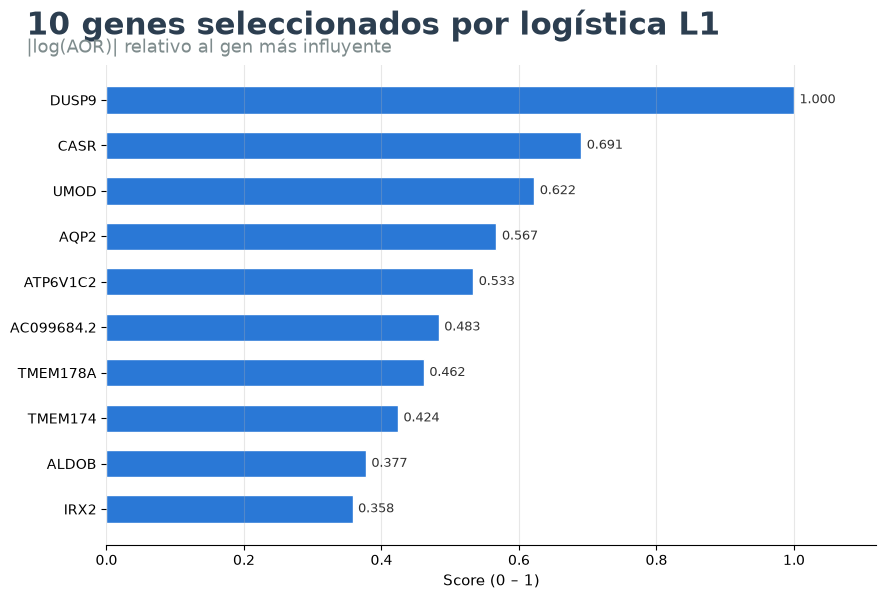

In [41]:
from utils.mutual_inf_plot import graficar_score_relevancia

importancia = (top_l1 / top_l1.max()).to_frame("importancia")
importancia.index = anotacion.loc[top_l1.index, "gene_name"]

graficar_score_relevancia(
    importancia,
    columna="importancia",
    titulo="10 genes seleccionados por logística L1",
    subtitulo="|log(AOR)| relativo al gen más influyente",
    color="#2a78d6",
    figsize=(10, 6),
);

---
## Curaduría: ontología de los 10 genes

**Los diez tienen AOR < 1**, todos en dirección de tejido normal. La firma no
recoge genes que el tumor encienda, sino el programa del nefrón diferenciado
cuya pérdida acompaña al carcinoma papilar: son marcadores de segmentos
tubulares concretos (túbulo proximal, asa de Henle, túbulo distal, conducto
colector) más dos reguladores de esa identidad.

Ejemplo de lectura: *DUSP9* tiene AOR 0.639, es decir que cada desviación
estándar adicional de expresión multiplica por 0.64 las odds de que la muestra
sea tumor —las reduce ~36 %— ajustando por los otros nueve genes.

| Gen | AOR | Ontología / función | Relación con el KIRP |
| --- | --- | --- | --- |
| **DUSP9** | 0.639 | Fosfatasa de doble especificidad (MKP-4) que inactiva las MAPK | Freno de la vía MAPK: al perderse, esa señal proliferativa queda sin contrapeso |
| **CASR** | 0.734 | Receptor sensor de calcio (GPCR) del nefrón distal | Gobierna la reabsorción de Ca²⁺; se pierde con la identidad del túbulo distal |
| **UMOD** | 0.756 | Uromodulina (proteína de Tamm-Horsfall), exclusiva de la rama ascendente gruesa | Gen más expresado de la firma (TPM medio 883) y de mayor varianza: marcador clásico de nefrón funcional |
| **AQP2** | 0.775 | Acuaporina 2, canal de agua del conducto colector regulado por vasopresina | Marcador de conducto colector diferenciado |
| **ATP6V1C2** | 0.787 | Subunidad C2 de la V-ATPasa, células intercaladas | Acidificación urinaria; función propia del conducto colector |
| **AC099684.2** | 0.805 | lncRNA sin función establecida | Señal de que la selección no se limita a genes codificantes |
| **TMEM178A** | 0.813 | Proteína transmembrana poco caracterizada, descrita como reguladora negativa de la señalización de calcio | Papel en riñón aún no establecido; se apoya en el resto de la firma |
| **TMEM174** | 0.827 | Proteína transmembrana de expresión prácticamente restringida al riñón | Marcador de túbulo proximal |
| **ALDOB** | 0.844 | Aldolasa B, metabolismo de fructosa y gluconeogénesis en túbulo proximal | Su caída es un hallazgo repetido en carcinoma renal: reprogramación metabólica del tumor |
| **IRX2** | 0.852 | Factor de transcripción homeobox Iroquois-2 | Regulador del desarrollo y la segmentación del nefrón |

**Tres salvedades.** Las AOR vienen de un ajuste penalizado: están encogidas
hacia 1, son conservadoras y esta estimación no produce valores p ni intervalos
de confianza. El contraste es tumor contra tejido normal adyacente, así que
habla del desarrollo del tumor y de su diagnóstico, no de agresividad ni
supervivencia, que exigirían modelar estadio o tiempo de seguimiento. Y por la
correlación entre genes, esta lista es *una* firma válida entre varias casi
equivalentes, no la única.